# What's Wrong with Salinity Structure



## Problems

1. How come that there are zig-zags in Halocline depth? 

2. Why HRDPS 2.5 has strange surface salinity at Pam Rocks and Puget Sound?

Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Central_SoG_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Juan_de_Fuca_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Haro_Strait_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Northern_SoG_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Puget_Sound_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Pam_Rocks_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_c

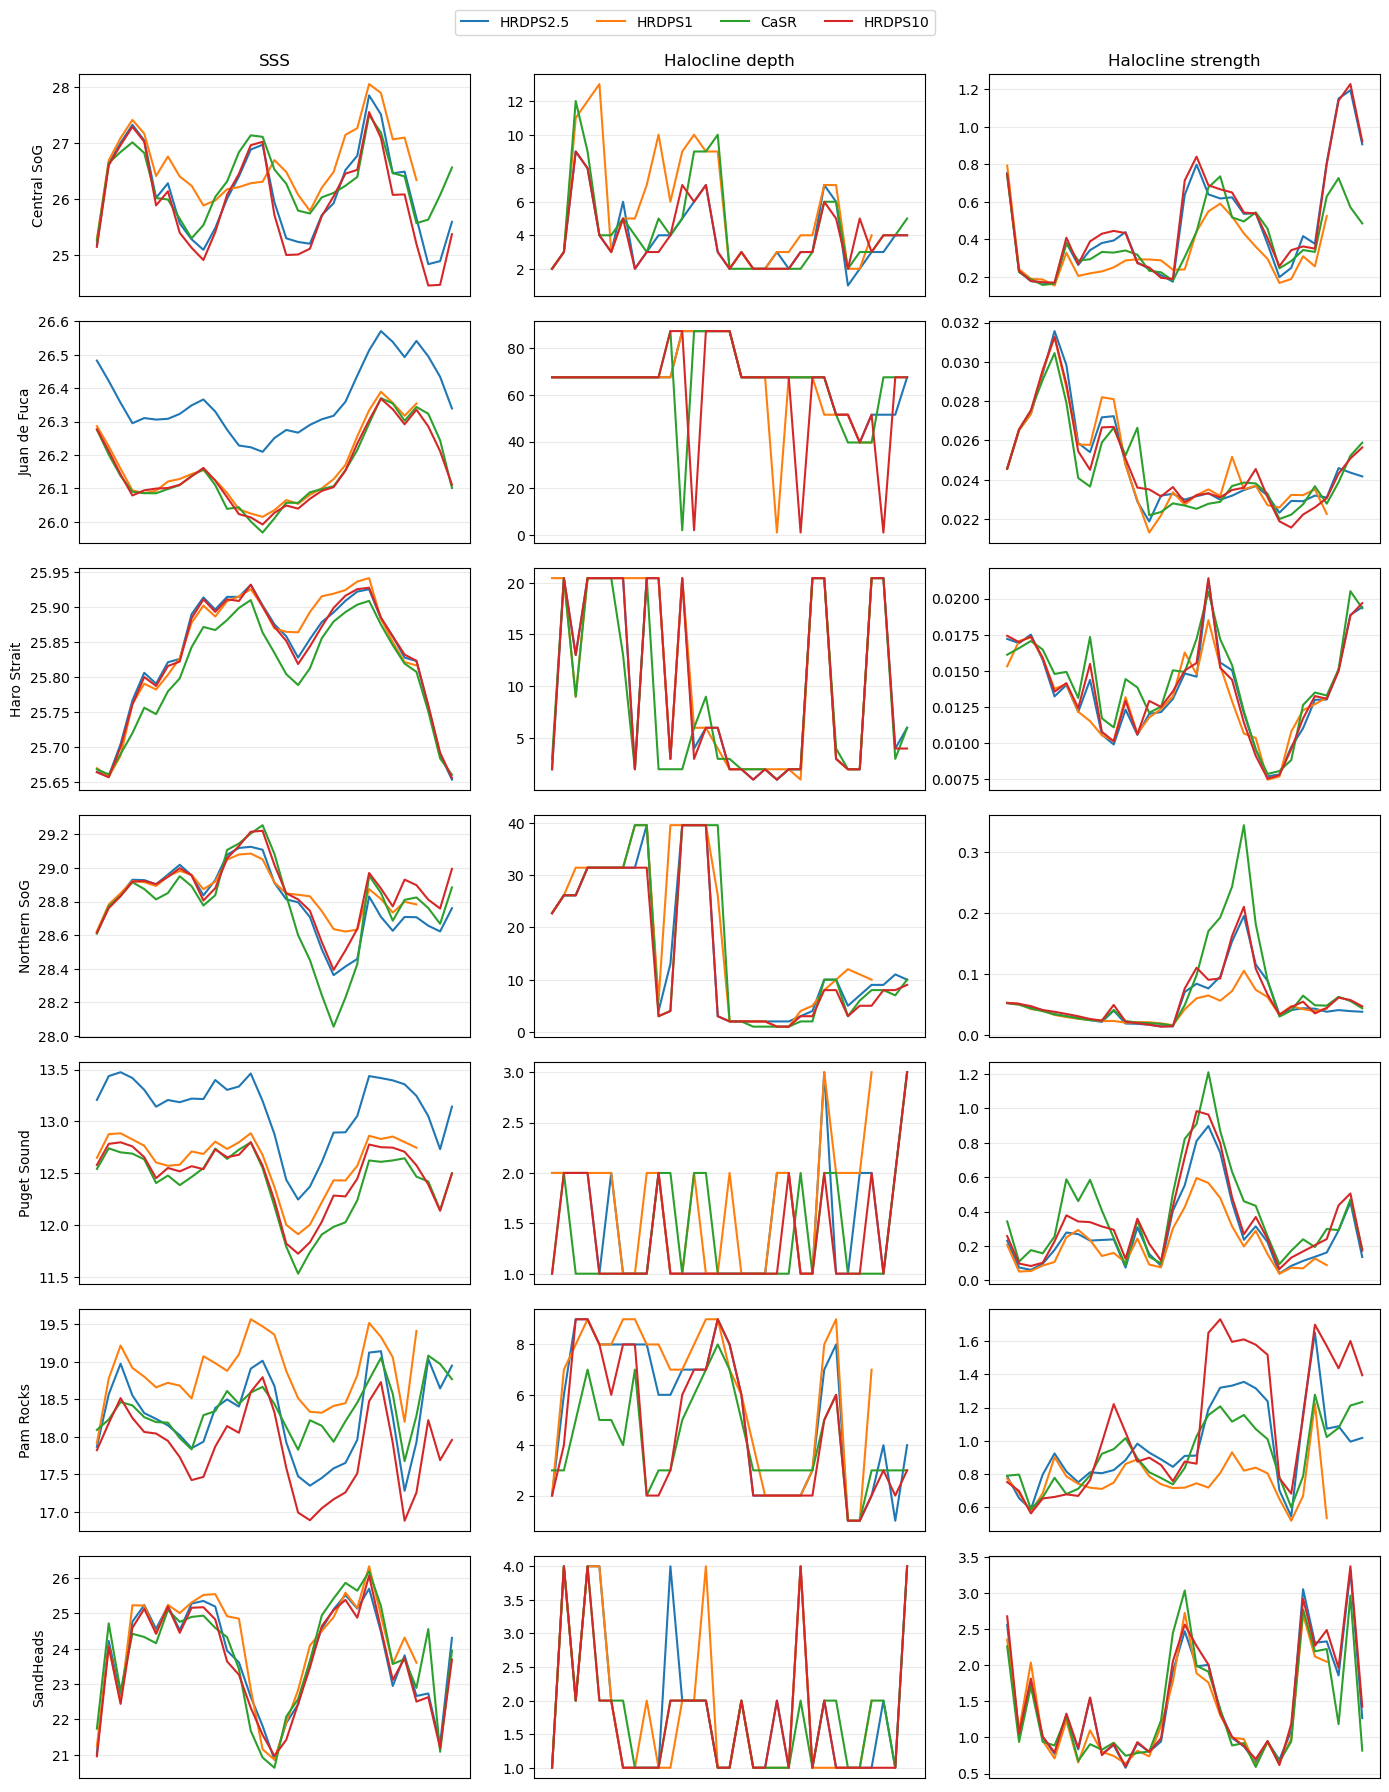

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATH
# ============================================================

DATA_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare_old/physical"
)


# ============================================================
# 2. SETTINGS
# ============================================================

REGIONS = [
    "Central SoG",
    "Juan de Fuca",
    "Haro Strait",
    "Northern SoG",
    "Puget Sound",
    "Pam Rocks",
    "SandHeads",
]

MODELS = [
    "HRDPS2.5",
    "HRDPS1",
    "CaSR",
    "HRDPS10",
]

VARIABLES = [
    ("SSS", "SSS"),
    ("halocline_depth_m", "Halocline depth"),
    (
        "halocline_strength_psu_per_m",
        "Halocline strength",
    ),
]


# ============================================================
# 3. HELPERS
# ============================================================

def safe_filename(name):
    return name.replace(" ", "_")


# ============================================================
# 4. PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=len(REGIONS),
    ncols=len(VARIABLES),
    figsize=(14, 18),
)

for row, region in enumerate(REGIONS):

    filename = (
        DATA_DIR /
        f"{safe_filename(region)}_physical.csv"
    )

    print(f"Reading: {filename}")

    df = pd.read_csv(filename)

    # Just use array index as x-axis.
    x = range(len(df))

    for col, (var_name, var_title) in enumerate(VARIABLES):

        ax = axes[row, col]

        for model in MODELS:

            column_name = f"{model}__{var_name}"

            if column_name not in df.columns:
                print(
                    f"WARNING: missing column: "
                    f"{column_name}"
                )
                continue

            ax.plot(
                x,
                df[column_name],
                label=model,
                linewidth=1.5,
            )

        # Column title only on top row
        if row == 0:
            ax.set_title(var_title)

        # Region name only on left column
        if col == 0:
            ax.set_ylabel(region)

        # No time labels
        ax.set_xticks([])

        ax.grid(alpha=0.25)


# ============================================================
# 5. ONE SHARED LEGEND
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(MODELS),
    bbox_to_anchor=(0.5, 0.995),
)

plt.tight_layout(
    rect=[0, 0, 1, 0.975]
)

plt.show()

## Data Inspection and Check

### Sandheads Salinity Profile

The location (Grid Number) of Sandheads: `'y': 428, 'x': 293`.

In [2]:
# Extract Sandheads Data

from pathlib import Path

import pandas as pd
import xarray as xr


# ============================================================
# SETTINGS
# ============================================================

INPUT_FILE = (
    "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
    "SalishSea_1d_20230301_20230331_grid_T.nc"
)

OUTPUT_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/"
    "Problem_All_Compare"
)

Y = 428
X = 293


# ============================================================
# MAIN
# ============================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with xr.open_dataset(INPUT_FILE) as ds:

    # Extract salinity profile at Sandheads
    salinity = ds["vosaline"].isel(y=Y, x=X)

    # Make sure dimensions are depth × time
    salinity = salinity.transpose("deptht", "time_counter")

    # Convert to DataFrame:
    # rows    = depth
    # columns = time
    df = pd.DataFrame(
        salinity.values,
        index=salinity["deptht"].values,
        columns=pd.to_datetime(salinity["time_counter"].values),
    )

df.index.name = "depth_m"

output_file = OUTPUT_DIR / "CaSR_Sandheads_salinity_profile.csv"
df.to_csv(output_file)

print(f"Saved: {output_file}")
print(f"Shape (depth × time): {df.shape}")

Saved: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Problem_All_Compare/CaSR_Sandheads_salinity_profile.csv
Shape (depth × time): (40, 31)


### Salinity Profiles

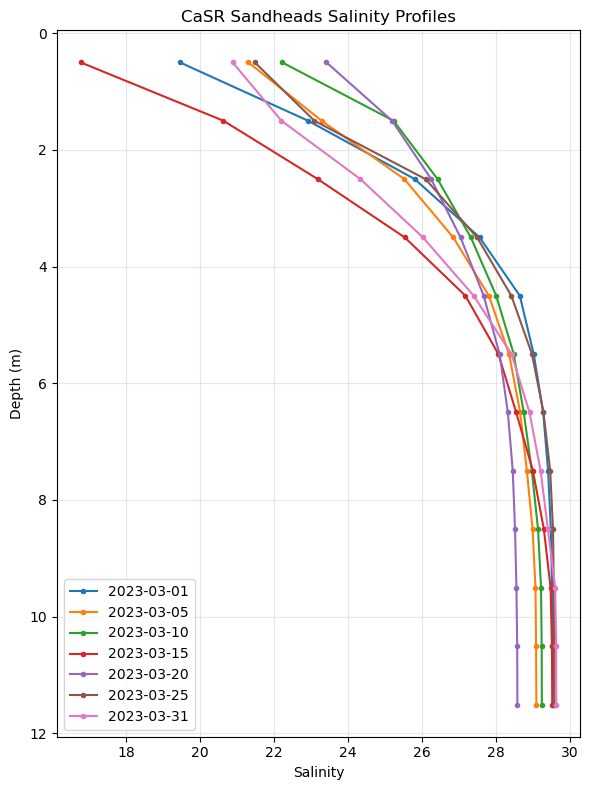

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

CSV_FILE = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/"
    "Problem_All_Compare/"
    "CaSR_Sandheads_salinity_profile.csv"
)


# ============================================================
# READ DATA
# ============================================================

df = pd.read_csv(CSV_FILE)

# 第一列是 depth
depth = df.iloc[:, 0].values

# 后面的列都是时间
time_columns = df.columns[1:]


# ============================================================
# PLOT SELECTED PROFILES
# ============================================================

# 选几天看看
selected_dates = [
    time_columns[0],
    time_columns[4],
    time_columns[9],
    time_columns[14],
    time_columns[19],
    time_columns[24],
    time_columns[-1],
]

plt.figure(figsize=(6, 8))

for date in selected_dates:

    salinity = df[date].values.copy()

    # 把海底以下的无效 0 去掉
    valid = salinity > 0

    plt.plot(
        salinity[valid],
        depth[valid],
        marker="o",
        markersize=3,
        label=pd.to_datetime(date).strftime("%Y-%m-%d"),
    )


plt.gca().invert_yaxis()

plt.xlabel("Salinity")
plt.ylabel("Depth (m)")
plt.title("CaSR Sandheads Salinity Profiles")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### How Deep are they? 

Find out the valid depth limits so better show the figures.



In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

CASR_T_FILE = Path(
    "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
    "SalishSea_1d_20230301_20230331_grid_T.nc"
)

# (j0, j1, i0, i1); slice end excluded.
REGIONS = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75, 125, 225, 280),
    "Pam Rocks":    (490, 510, 330, 350),
    "SandHeads":    (420, 440, 280, 300),
}


def main():
    with xr.open_dataset(CASR_T_FILE) as ds:
        if "vosaline" not in ds:
            raise KeyError(f"'vosaline' not found. Available: {list(ds.data_vars)}")

        sal = ds["vosaline"].isel(time_counter=0)
        depths = sal["deptht"].values
        time = ds["time_counter"].values[0]
        counts_by_region = {}
        cells_by_region = {}

        for name, (j0, j1, i0, i1) in REGIONS.items():
            # Shape: deptht, y, x. Load just one region at this single time.
            values = sal.isel(y=slice(j0, j1), x=slice(i0, i1)).values
            counts_by_region[name] = (
                np.isfinite(values) & (values > 0)
            ).sum(axis=(-2, -1)).astype(int)
            cells_by_region[name] = values.shape[-2] * values.shape[-1]

    # Shared depth axis: one row per depth, one column per region.
    table = pd.DataFrame(counts_by_region)
    table.index = pd.Index(
        [f"{k:>2d} | {float(depth):>8.2f}" for k, depth in enumerate(depths)],
        name="Level | Depth (m)",
    )

    print(f"\nCaSR salinity (vosaline) | first time point: {time}")
    print("Valid cell: finite salinity > 0  (same as non-NaN after .where(salinity > 0))")
    print("Each entry = number of valid grid cells at that depth in that region.\n")
    print(table.to_string(index=True))
    print("\nTotal grid cells per region (before filtering):")
    print("  " + " | ".join(f"{name}: {count}" for name, count in cells_by_region.items()))


if __name__ == "__main__":
    main()


CaSR salinity (vosaline) | first time point: 2023-03-01T12:00:00.000000000
Valid cell: finite salinity > 0  (same as non-NaN after .where(salinity > 0))
Each entry = number of valid grid cells at that depth in that region.

                   Central SoG  Juan de Fuca  Haro Strait  Northern SoG  Puget Sound  Pam Rocks  SandHeads
Level | Depth (m)                                                                                         
 0 |     0.50             2493          2704         1349          1979         1092        310        400
 1 |     1.50             2493          2704         1349          1979         1092        310        400
 2 |     2.50             2493          2704         1349          1979         1092        310        400
 3 |     3.50             2493          2704         1349          1979         1092        310        400
 4 |     4.50             2493          2688         1343          1977         1092        309        347
 5 |     5.50             

Valid Depth (by manually choosing):

1. Central SoG: 300 m
2. Juan de Fuca: 180
3. Haro Strait: 75 m
4. Northern SoG: 200 m
5. Puget Sound: 175 m
6. Pam Rocks: 250 m
7. Sandheads: 120 m


## Better Range 

Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Central_SoG_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Juan_de_Fuca_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Haro_Strait_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Northern_SoG_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Puget_Sound_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Pam_Rocks_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_c

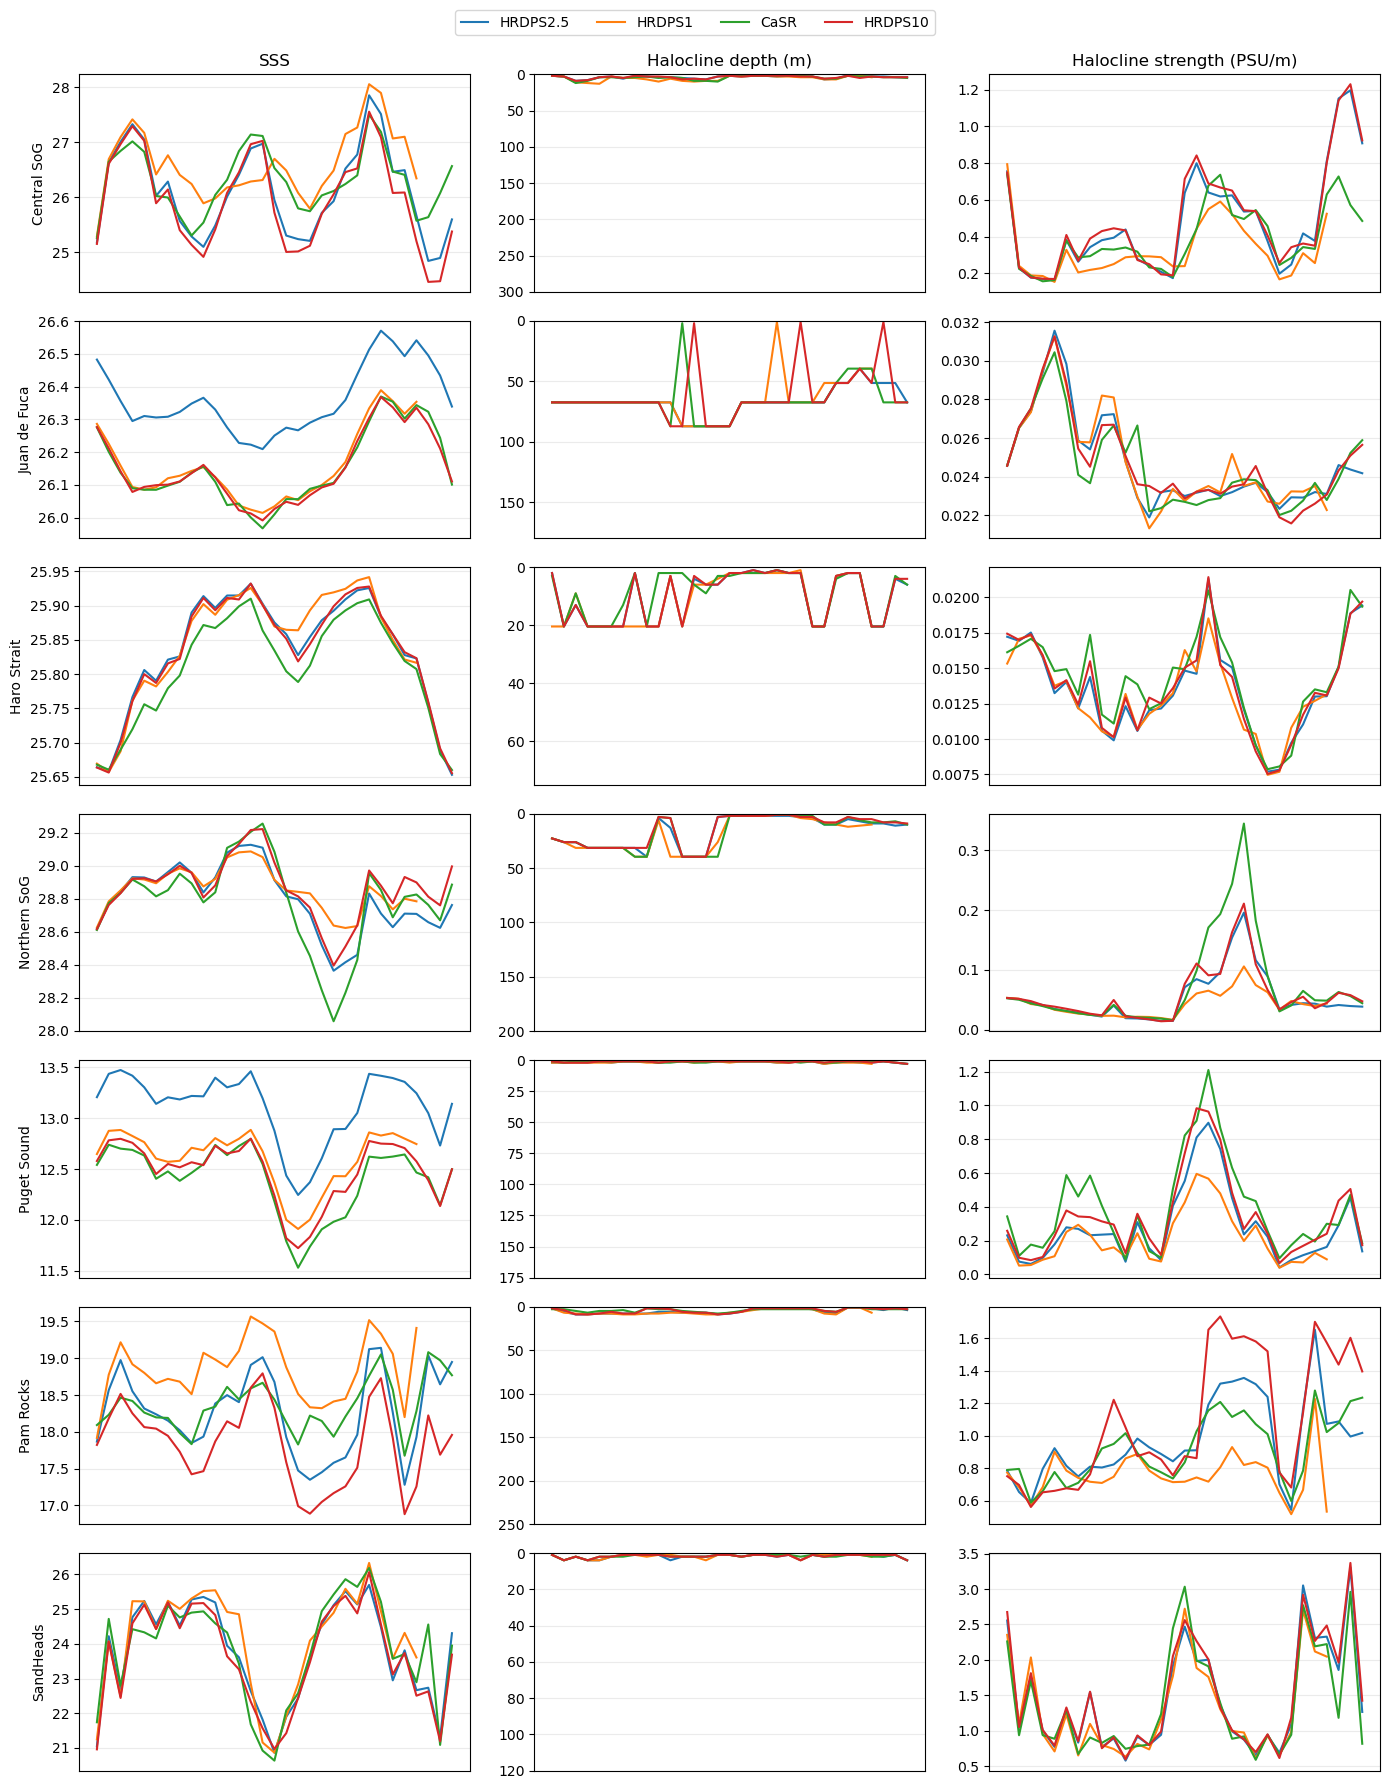

In [4]:

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATH
# ============================================================

DATA_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/physical"
)


# ============================================================
# 2. SETTINGS
# ============================================================

REGIONS = [
    "Central SoG",
    "Juan de Fuca",
    "Haro Strait",
    "Northern SoG",
    "Puget Sound",
    "Pam Rocks",
    "SandHeads",
]

MODELS = [
    "HRDPS2.5",
    "HRDPS1",
    "CaSR",
    "HRDPS10",
]

VARIABLES = [
    ("SSS", "SSS"),
    ("halocline_depth_m", "Halocline depth (m)"),
    (
        "halocline_strength_psu_per_m",
        "Halocline strength (PSU/m)",
    ),
]

# Manually selected valid depths (m)
VALID_DEPTHS = {
    "Central SoG": 300,
    "Juan de Fuca": 180,
    "Haro Strait": 75,
    "Northern SoG": 200,
    "Puget Sound": 175,
    "Pam Rocks": 250,
    "SandHeads": 120,
}


# ============================================================
# 3. HELPERS
# ============================================================

def safe_filename(name):
    return name.replace(" ", "_")


# ============================================================
# 4. PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=len(REGIONS),
    ncols=len(VARIABLES),
    figsize=(14, 18),
)

for row, region in enumerate(REGIONS):

    filename = (
        DATA_DIR /
        f"{safe_filename(region)}_physical.csv"
    )

    print(f"Reading: {filename}")

    df = pd.read_csv(filename)

    # Just use array index as x-axis
    x = range(len(df))

    valid_depth = VALID_DEPTHS[region]

    for col, (var_name, var_title) in enumerate(VARIABLES):

        ax = axes[row, col]

        for model in MODELS:

            column_name = f"{model}__{var_name}"

            if column_name not in df.columns:
                print(
                    f"WARNING: missing column: "
                    f"{column_name}"
                )
                continue

            ax.plot(
                x,
                df[column_name],
                label=model,
                linewidth=1.5,
            )

        # Column title only on top row
        if row == 0:
            ax.set_title(var_title)

        # Region name only on left column
        if col == 0:
            ax.set_ylabel(region)

        # Apply manually selected valid depth
        # Only to halocline depth
        if var_name == "halocline_depth_m":
            ax.set_ylim(valid_depth, 0)

        # No time labels
        ax.set_xticks([])

        ax.grid(alpha=0.25)


# ============================================================
# 5. ONE SHARED LEGEND
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(MODELS),
    bbox_to_anchor=(0.5, 0.995),
)

plt.tight_layout(
    rect=[0, 0, 1, 0.975]
)

plt.show()


## Why HRDPS 2.5 has higher SSS at Juan de Fuca and Puget Sound?

### pcolor in Salish Sea, HRDPS 2.5 vs CaSR

Date        : 20230301
Time index  : 0
CaSR time   : 2023-03-01T12:00:00.000000000
HRDPS time  : 2023-03-01T12:00:00.000000000
CaSR shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230315
Time index  : 14
CaSR time   : 2023-03-15T12:00:00.000000000
HRDPS time  : 2023-03-15T12:00:00.000000000
CaSR shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230331
Time index  : 30
CaSR time   : 2023-03-31T12:00:00.000000000
HRDPS time  : 2023-03-31T12:00:00.000000000
CaSR shape  : (898, 398)
HRDPS shape : (898, 398)

Color ranges:
SSS  : 0.000 to 32.331 
Diff : -4.739 to 4.739 


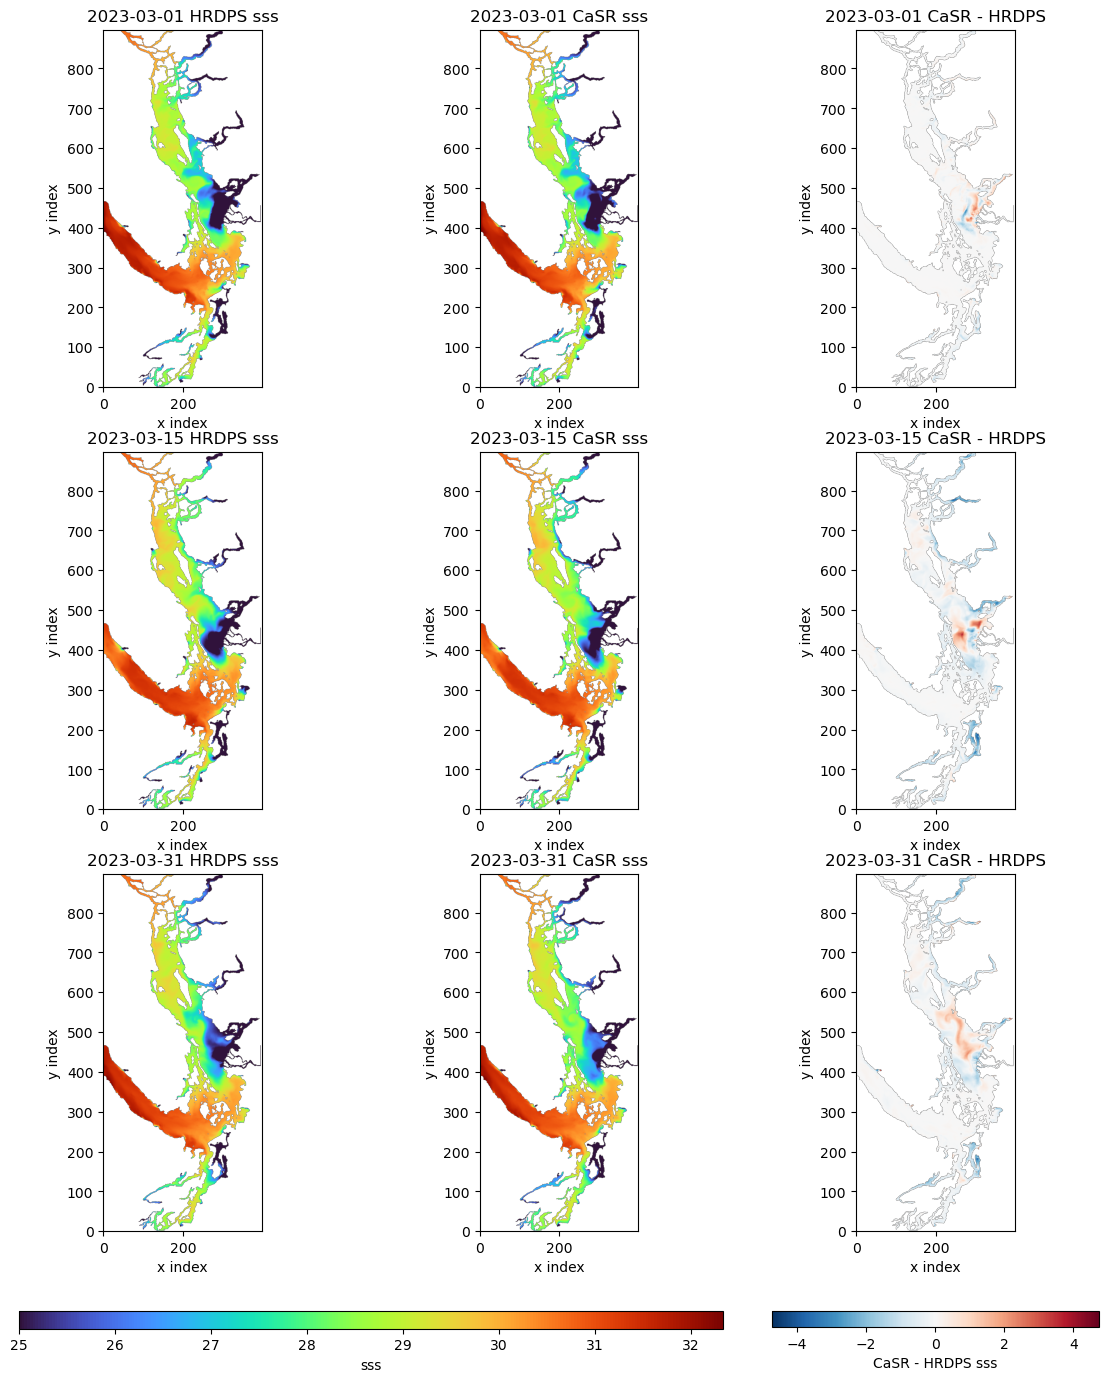

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# 1d grid_T files
# ============================================================
path_grid_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_grid_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_grid_casr)
hrdps_ds = xr.open_dataset(path_grid_hrdps)


# ============================================================
# Choose 3 days
#
# For 1d monthly files:
# March 1  -> time index 0
# March 15 -> time index 14
# March 31 -> time index 30
# ============================================================
days = [
    "20230301",
    "20230315",
    "20230331",
]

day_numbers = [1, 15, 31]

depth_idx = 0


# ============================================================
# Read SSS data
# ============================================================
all_data = []

for date_str, day_num in zip(days, day_numbers):

    # ========================================================
    # Time index for 1d monthly file
    # ========================================================
    tidx = day_num - 1


    # ========================================================
    # SSS
    # ========================================================
    casr_sss = casr_ds['vosaline'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values

    # casr_sss = casr_sss.where(casr_sss > 0)
    # numpy does not support using where like this

    casr_sss = np.where(casr_sss > 0, casr_sss, np.nan)

    hrdps_sss = hrdps_ds['vosaline'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values

    hrdps_sss = np.where(hrdps_sss > 0, hrdps_sss, np.nan)


    # hrdps_sss = hrdps_sss.where(hrdps_sss>0)


    # ========================================================
    # Difference
    # positive = CaSR warmer than HRDPS
    # ========================================================
    diff = casr_sss - hrdps_sss


    # ========================================================
    # Time information
    # ========================================================
    casr_time = casr_ds.time_counter.isel(
        time_counter=tidx
    ).values

    hrdps_time = hrdps_ds.time_counter.isel(
        time_counter=tidx
    ).values


    print("=" * 60)
    print(f"Date        : {date_str}")
    print(f"Time index  : {tidx}")
    print(f"CaSR time   : {casr_time}")
    print(f"HRDPS time  : {hrdps_time}")
    print(f"CaSR shape  : {casr_sss.shape}")
    print(f"HRDPS shape : {hrdps_sss.shape}")


    # ========================================================
    # Save for plotting
    # ========================================================
    all_data.append({
        'date': date_str,
        'hrdps': hrdps_sss,
        'casr': casr_sss,
        'diff': diff,
    })


# ============================================================
# Unified sss color range
# across all 3 days and both datasets
# ============================================================
all_sss_values = []

for data in all_data:

    all_sss_values.append(
        data['hrdps'][np.isfinite(data['hrdps'])]
    )

    all_sss_values.append(
        data['casr'][np.isfinite(data['casr'])]
    )

all_sss_values = np.concatenate(all_sss_values)

sss_vmin = np.nanmin(all_sss_values)
sss_vmax = np.nanmax(all_sss_values)


# ============================================================
# Unified difference color range
# symmetric around zero
# ============================================================
all_diff_values = []

for data in all_data:

    all_diff_values.append(
        data['diff'][np.isfinite(data['diff'])]
    )

all_diff_values = np.concatenate(all_diff_values)

diff_max = np.nanmax(np.abs(all_diff_values))

diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)


print("\nColor ranges:")
print(f"SSS  : {sss_vmin:.3f} to {sss_vmax:.3f} ")
print(f"Diff : {-diff_max:.3f} to {diff_max:.3f} ")


# ============================================================
# Plot: 3 rows × 3 columns
#
# column 1: HRDPS SSS
# column 2: CaSR SSS
# column 3: CaSR - HRDPS
# ============================================================
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 16)
)


for row, data in enumerate(all_data):

    date_str = data['date']

    hrdps_sss = data['hrdps']
    casr_sss = data['casr']
    diff = data['diff']

    date_label = (
        f'{date_str[:4]}-'
        f'{date_str[4:6]}-'
        f'{date_str[6:]}'
    )


    # ========================================================
    # HRDPS sss
    # ========================================================
    im_sss = axes[row, 0].imshow(
        hrdps_sss,
        origin='lower',
        cmap='turbo',
        vmin=25,
        vmax=sss_vmax,
        aspect='equal'
    )

    axes[row, 0].set_title(
        f'{date_label} HRDPS sss'
    )

    axes[row, 0].set_xlabel('x index')
    axes[row, 0].set_ylabel('y index')


    # ========================================================
    # CaSR sss
    # ========================================================
    axes[row, 1].imshow(
        casr_sss,
        origin='lower',
        cmap='turbo',
        #vmin=sss_vmin,
        vmin=25,
        vmax=sss_vmax,
        aspect='equal'
    )

    axes[row, 1].set_title(
        f'{date_label} CaSR sss'
    )

    axes[row, 1].set_xlabel('x index')
    axes[row, 1].set_ylabel('y index')


    # ========================================================
    # Difference
    # ========================================================
    im_diff = axes[row, 2].imshow(
        diff,
        origin='lower',
        cmap='RdBu_r',
        norm=diff_norm,
        aspect='equal'
    )

    axes[row, 2].set_title(
        f'{date_label} CaSR - HRDPS'
    )

    axes[row, 2].set_xlabel('x index')
    axes[row, 2].set_ylabel('y index')


# ============================================================
# Adjust space
# leave space at bottom for horizontal colorbars
# ============================================================
plt.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.95,
    bottom=0.12,
    wspace=0.15,
    hspace=0.18
)


# ============================================================
# sss colorbar
# shared by first two columns
# ============================================================
cbar_sss = fig.colorbar(
    im_sss,
    ax=axes[:, 0:2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=40
)

cbar_sss.set_label('sss')


# ============================================================
# Difference colorbar
# shared by third column
# ============================================================
cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[:, 2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=20
)

cbar_diff.set_label('CaSR - HRDPS sss')


plt.show()


# ============================================================
# Close files
# ============================================================
casr_ds.close()
hrdps_ds.close()

### pcolor at Juan de Fuca, HRDPS 2.5 vs CaSR

Region      : Juan de Fuca
Date        : 20230301
Time index  : 0
CaSR time   : 2023-03-01T12:00:00.000000000
HRDPS time  : 2023-03-01T12:00:00.000000000
CaSR shape  : (65, 50)
HRDPS shape : (65, 50)
Region      : Juan de Fuca
Date        : 20230315
Time index  : 14
CaSR time   : 2023-03-15T12:00:00.000000000
HRDPS time  : 2023-03-15T12:00:00.000000000
CaSR shape  : (65, 50)
HRDPS shape : (65, 50)
Region      : Juan de Fuca
Date        : 20230331
Time index  : 30
CaSR time   : 2023-03-31T12:00:00.000000000
HRDPS time  : 2023-03-31T12:00:00.000000000
CaSR shape  : (65, 50)
HRDPS shape : (65, 50)

Color ranges:
SSS  : 28.066 to 31.898
Diff : -0.459 to 0.459


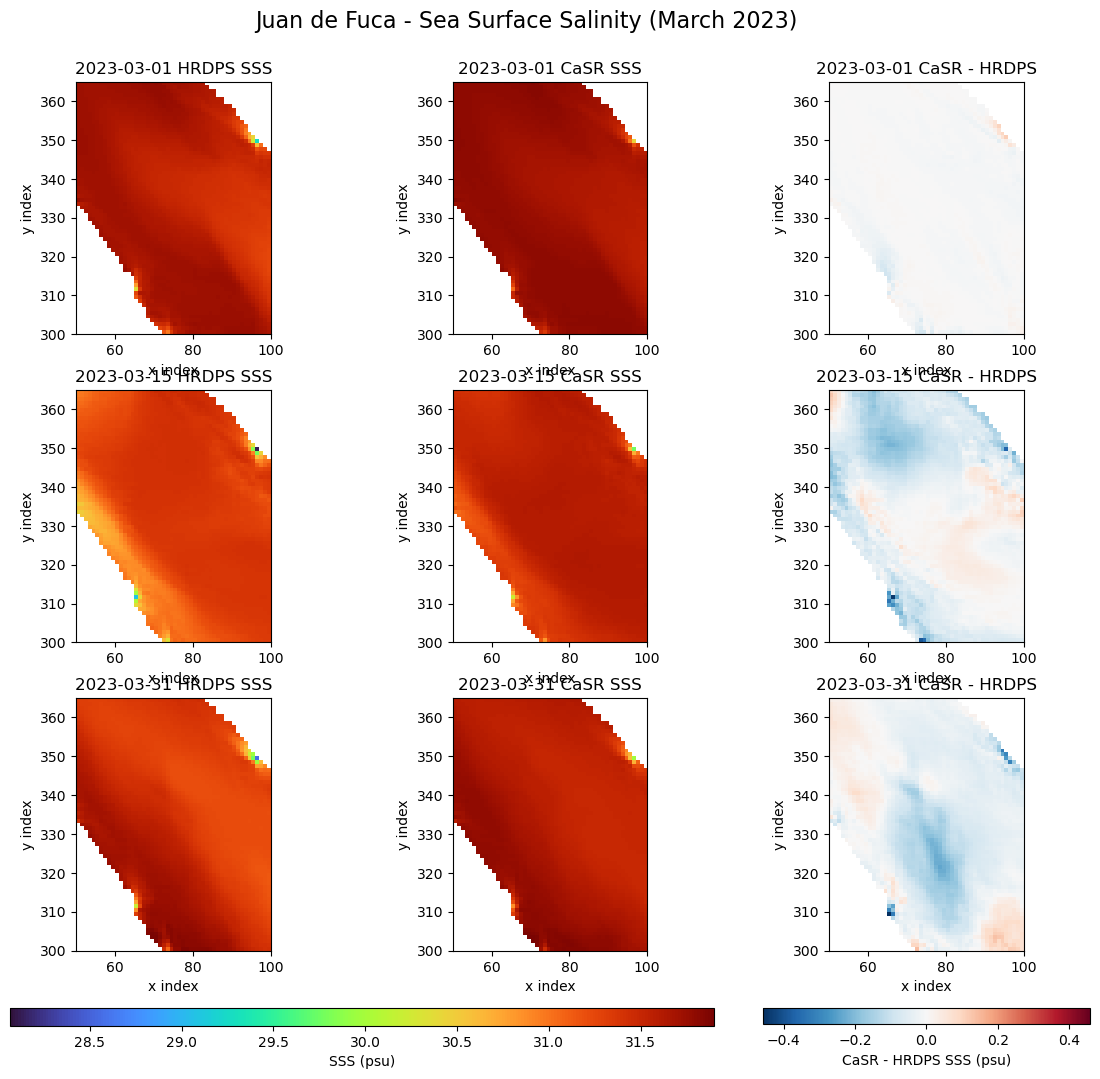

In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# 1d grid_T files
# ============================================================
path_grid_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_grid_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_grid_casr)
hrdps_ds = xr.open_dataset(path_grid_hrdps)


# ============================================================
# Juan de Fuca region
# (xmin, xmax, ymin, ymax)
# ============================================================
# Juan de Fuca (j0, j1, i0, i1)
j0, j1, i0, i1 = 300, 365, 50, 100

ymin, ymax = j0, j1
xmin, xmax = i0, i1


# ============================================================
# Choose 3 days
# ============================================================
days = [
    "20230301",
    "20230315",
    "20230331",
]

day_numbers = [1, 15, 31]

depth_idx = 0


# ============================================================
# Read SSS data for Juan de Fuca only
# ============================================================
all_data = []

for date_str, day_num in zip(days, day_numbers):

    tidx = day_num - 1

    # ========================================================
    # CaSR SSS - Juan de Fuca
    # ========================================================
    casr_sss = casr_ds['vosaline'].isel(
        time_counter=tidx,
        deptht=depth_idx,
        y=slice(ymin, ymax),
        x=slice(xmin, xmax)
    ).values

    casr_sss = np.where(
        casr_sss > 0,
        casr_sss,
        np.nan
    )

    # ========================================================
    # HRDPS SSS - Juan de Fuca
    # ========================================================
    hrdps_sss = hrdps_ds['vosaline'].isel(
        time_counter=tidx,
        deptht=depth_idx,
        y=slice(ymin, ymax),
        x=slice(xmin, xmax)
    ).values

    hrdps_sss = np.where(
        hrdps_sss > 0,
        hrdps_sss,
        np.nan
    )

    # ========================================================
    # Difference
    # ========================================================
    diff = casr_sss - hrdps_sss

    # ========================================================
    # Time information
    # ========================================================
    casr_time = casr_ds.time_counter.isel(
        time_counter=tidx
    ).values

    hrdps_time = hrdps_ds.time_counter.isel(
        time_counter=tidx
    ).values

    print("=" * 60)
    print(f"Region      : {region}")
    print(f"Date        : {date_str}")
    print(f"Time index  : {tidx}")
    print(f"CaSR time   : {casr_time}")
    print(f"HRDPS time  : {hrdps_time}")
    print(f"CaSR shape  : {casr_sss.shape}")
    print(f"HRDPS shape : {hrdps_sss.shape}")

    all_data.append({
        'date': date_str,
        'hrdps': hrdps_sss,
        'casr': casr_sss,
        'diff': diff,
    })


# ============================================================
# Unified SSS color range
# Juan de Fuca only
# ============================================================
all_sss_values = []

for data in all_data:

    all_sss_values.append(
        data['hrdps'][np.isfinite(data['hrdps'])]
    )

    all_sss_values.append(
        data['casr'][np.isfinite(data['casr'])]
    )

all_sss_values = np.concatenate(all_sss_values)

sss_vmin = np.nanmin(all_sss_values)
sss_vmax = np.nanmax(all_sss_values)


# ============================================================
# Unified difference color range
# Juan de Fuca only
# ============================================================
all_diff_values = []

for data in all_data:

    all_diff_values.append(
        data['diff'][np.isfinite(data['diff'])]
    )

all_diff_values = np.concatenate(all_diff_values)

diff_max = np.nanmax(np.abs(all_diff_values))

diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)


print("\nColor ranges:")
print(f"SSS  : {sss_vmin:.3f} to {sss_vmax:.3f}")
print(f"Diff : {-diff_max:.3f} to {diff_max:.3f}")


# ============================================================
# Plot: 3 rows × 3 columns
# Juan de Fuca only
# ============================================================
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12)
)

for row, data in enumerate(all_data):

    date_str = data['date']

    hrdps_sss = data['hrdps']
    casr_sss = data['casr']
    diff = data['diff']

    date_label = (
        f'{date_str[:4]}-'
        f'{date_str[4:6]}-'
        f'{date_str[6:]}'
    )

    # Show original grid indices on axes
    extent = [xmin, xmax, ymin, ymax]

    # ========================================================
    # HRDPS SSS
    # ========================================================
    im_sss = axes[row, 0].imshow(
        hrdps_sss,
        origin='lower',
        extent=extent,
        cmap='turbo',
        vmin=sss_vmin,
        vmax=sss_vmax,
        aspect='equal'
    )

    axes[row, 0].set_title(
        f'{date_label} HRDPS SSS'
    )

    axes[row, 0].set_xlabel('x index')
    axes[row, 0].set_ylabel('y index')

    # ========================================================
    # CaSR SSS
    # ========================================================
    axes[row, 1].imshow(
        casr_sss,
        origin='lower',
        extent=extent,
        cmap='turbo',
        vmin=25,
        vmax=sss_vmax,
        aspect='equal'
    )

    axes[row, 1].set_title(
        f'{date_label} CaSR SSS'
    )

    axes[row, 1].set_xlabel('x index')
    axes[row, 1].set_ylabel('y index')

    # ========================================================
    # Difference
    # ========================================================
    im_diff = axes[row, 2].imshow(
        diff,
        origin='lower',
        extent=extent,
        cmap='RdBu_r',
        norm=diff_norm,
        aspect='equal'
    )

    axes[row, 2].set_title(
        f'{date_label} CaSR - HRDPS'
    )

    axes[row, 2].set_xlabel('x index')
    axes[row, 2].set_ylabel('y index')


# ============================================================
# Figure title
# ============================================================
fig.suptitle(
    'Juan de Fuca - Sea Surface Salinity (March 2023)',
    fontsize=16,
    y=0.98
)


# ============================================================
# Adjust spacing
# ============================================================
plt.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.92,
    bottom=0.12,
    wspace=0.15,
    hspace=0.22
)


# ============================================================
# SSS colorbar
# ============================================================
cbar_sss = fig.colorbar(
    im_sss,
    ax=axes[:, 0:2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=40
)

cbar_sss.set_label('SSS (psu)')


# ============================================================
# Difference colorbar
# ============================================================
cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[:, 2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=20
)

cbar_diff.set_label('CaSR - HRDPS SSS (psu)')


plt.show()


# ============================================================
# Close files
# ============================================================
casr_ds.close()
hrdps_ds.close()

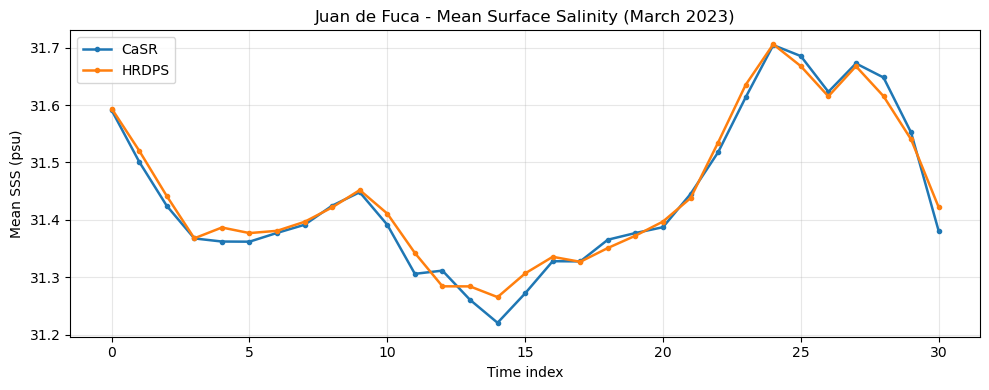

In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Files
# ============================================================
path_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

# ============================================================
# Juan de Fuca: (j0, j1, i0, i1)
# ============================================================
j0, j1, i0, i1 = 300, 365, 50, 100

casr_ds = xr.open_dataset(path_casr)
hrdps_ds = xr.open_dataset(path_hrdps)

# ============================================================
# Surface SSS, all time indices
# ============================================================
casr = casr_ds['vosaline'].isel(
    deptht=0,
    y=slice(j0, j1),
    x=slice(i0, i1)
)

hrdps = hrdps_ds['vosaline'].isel(
    deptht=0,
    y=slice(j0, j1),
    x=slice(i0, i1)
)

# Remove invalid values
casr = casr.where(casr > 0)
hrdps = hrdps.where(hrdps > 0)

# ============================================================
# Spatial mean for each time index
# ============================================================
casr_mean = casr.mean(dim=['y', 'x'], skipna=True).values
hrdps_mean = hrdps.mean(dim=['y', 'x'], skipna=True).values

# Use index only
time_idx = np.arange(len(casr_mean))

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10, 4))

plt.plot(
    time_idx, casr_mean,
    '-o', label='CaSR',
    linewidth=1.8, markersize=3
)

plt.plot(
    time_idx, hrdps_mean,
    '-o', label='HRDPS',
    linewidth=1.8, markersize=3
)

plt.xlabel('Time index')
plt.ylabel('Mean SSS (psu)')
plt.title('Juan de Fuca - Mean Surface Salinity (March 2023)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

casr_ds.close()
hrdps_ds.close()

### Diagnosis

Why we don't see it now?

**I'm using HRDPS 2.5 flux out put this time, generated lately.** 

Maybe something happened that changed the HRDPS 